# Analiza i priprema skupa podataka

Predikcija srčane slabosti primenom metoda mašinskog učenja.


In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [28]:
np.random.seed(7)

# Učitavanje skupa podataka

Skup podataka nad kojim radimo je *Heart Failure Prediction* skup sa Kaggle-a. Nastao je spajanjem pet kardioloških skupova iz UCI repozitorijuma. Za svakog pacijenta dato je jedanaest kliničkih pokazatelja koji se prikupljaju na rutinskom kardiološkom pregledu, a ciljna promenljiva <code>HeartDisease</code> govori da li pacijent ima srčano oboljenje (1) ili nema (0).

In [ ]:
data = pd.read_csv('../data/heart.csv')

Prvih pet instanci skupa podataka:

In [48]:
data.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


Dimenzije skupa podataka:

In [50]:
data.shape

(918, 12)

Skup podataka ima 918 instanci i 12 kolona, od kojih je jedanaest atributa, a jedna je ciljna promenljiva. Značenje atributa je sledeće:

* <code>Age</code> - starost pacijenta u godinama
* <code>Sex</code> - pol pacijenta (M, F)
* <code>ChestPainType</code> - tip bola u grudima (TA - tipična angina, ATA - atipična angina, NAP - bol koji nije anginozni, ASY - bez simptoma)
* <code>RestingBP</code> - krvni pritisak u mirovanju u mm Hg
* <code>Cholesterol</code> - holesterol u serumu u mg/dl
* <code>FastingBS</code> - nivo glukoze u krvi veći od 120 mg/dl (1 – jeste, 0 – nije)
* <code>RestingECG</code> - nalaz EKG-a u mirovanju (Normal, ST, LVH)
* <code>MaxHR</code> - maksimalna izmerena srčana frekvencija
* <code>ExerciseAngina</code> - angina izazvana naporom (Y, N)
* <code>Oldpeak</code> - ST depresija izmerena pri naporu
* <code>ST_Slope</code> - nagib ST segmenta pri naporu (Up, Flat, Down)

Osnovne informacije o atributima, njihove tipove i uvid u prisustvo nedostajućih vrednosti:

In [52]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 97.6 KB


Vidimo da pet atributa nije numeričkog tipa, već su u pitanju niske koje označavaju kategorije. Pre pravljenja modela njih je neophodno pretvoriti u numerički oblik.

Elementarne statistike numeričkih atributa:

In [54]:
data.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


Iz ove tabele se vidi da su skale atributa vrlo različite. Vrednosti atributa <code>Oldpeak</code> su u rasponu od -2.6 do 6.2, dok su vrednosti atributa <code>Cholesterol</code> u rasponu od 0 do 603. Zbog toga će biti potrebno izvršiti standardizaciju.

Takođe, primećujemo nešto što nije fiziološki moguće: minimalna vrednost atributa <code>Cholesterol</code> je 0, a i minimalna vrednost atributa <code>RestingBP</code> je 0. Ovim ćemo se baviti u nastavku.

# Ciljna promenljiva

Broj instanci po klasama:

In [55]:
data['HeartDisease'].value_counts()

HeartDisease
1    508
0    410
Name: count, dtype: int64

In [57]:
np.bincount(data['HeartDisease'])

array([410, 508])

Grafički prikaz udela zdravih i bolesnih pacijenata u skupu podataka:

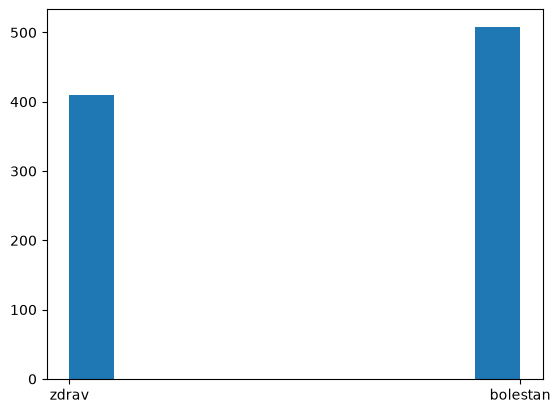

In [58]:
plt.hist(data['HeartDisease'])
plt.xticks([0, 1], labels=['zdrav', 'bolestan'])
plt.show()

Klase su nebalansirane, 508 bolesnih naspram 410 zdravih pacijenata, odnosno 55.3% prema 44.7%. Prilikom podele skupa podataka koristićemo stratifikaciju, a pored tačnosti pratićemo i preciznost, odziv i F1 meru.

# Nedostajuće vrednosti

Broj nedostajućih vrednosti po kolonama:

In [61]:
data.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

Prethodnom linijom koda mogli smo da zaključimo da nema nedostajućih vrednosti. Međutim, videli smo da atributi <code>Cholesterol</code> i <code>RestingBP</code> uzimaju vrednost 0, što je fiziološki nemoguće. Reč je o merenjima koja nisu obavljena, a upisana su kao nule.

Broj nula u koloni <code>Cholesterol</code>:

In [62]:
(data['Cholesterol'] == 0).sum()

np.int64(172)

Broj nula u koloni <code>RestingBP</code>:

In [63]:
(data['RestingBP'] == 0).sum()

np.int64(1)

Raspodela vrednosti holesterola, na kojoj se nule jasno vide kao zaseban stubić levo:

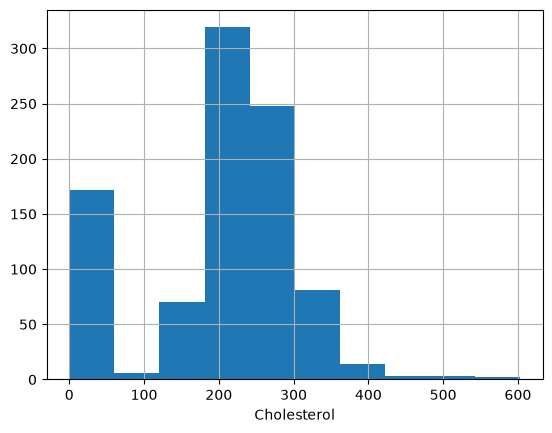

In [64]:
data['Cholesterol'].hist()
plt.xlabel('Cholesterol')
plt.show()

Nula je čak 172, što je 18.7% skupa podataka i previše da bismo te instance izbacili. Zato ćemo nule zameniti medijanom izmerenih vrednosti.

Pre toga uvodimo novi atribut <code>Cholesterol_izmeren</code> koji pamti da li je merenje uopšte obavljeno. Sama činjenica da merenje nedostaje može da nosi informaciju, pa je ne želimo izgubiti zamenom.

In [65]:
data['Cholesterol_izmeren'] = (data['Cholesterol'] != 0).astype(int)

Prosečna vrednost ciljne promenljive u obe grupe, odnosno udeo bolesnih:

In [66]:
data.groupby('Cholesterol_izmeren')['HeartDisease'].mean()

Cholesterol_izmeren
0    0.883721
1    0.477212
Name: HeartDisease, dtype: float64

Razlika je velika. Među pacijentima kojima holesterol nije izmeren 88.4% ima srčano oboljenje, dok je među ostalima taj udeo 47.7%.

Medijana izmerenih vrednosti holesterola:

In [67]:
mediana_holesterola = data.loc[data['Cholesterol'] != 0, 'Cholesterol'].median()
mediana_holesterola

np.float64(237.0)

In [69]:
data['Cholesterol'] = data['Cholesterol'].replace(0, mediana_holesterola)

Isto radimo i sa jedinom nulom u koloni <code>RestingBP</code>:

In [70]:
mediana_pritiska = data.loc[data['RestingBP'] != 0, 'RestingBP'].median()
mediana_pritiska

np.float64(130.0)

In [71]:
data['RestingBP'] = data['RestingBP'].replace(0, mediana_pritiska)

Provera da nula više nema:

In [72]:
(data['Cholesterol'] == 0).sum()

np.int64(0)

In [73]:
(data['RestingBP'] == 0).sum()

np.int64(0)

# Analiza atributa

Grafički prikaz raspodela pojedinačnih numeričkih atributa:

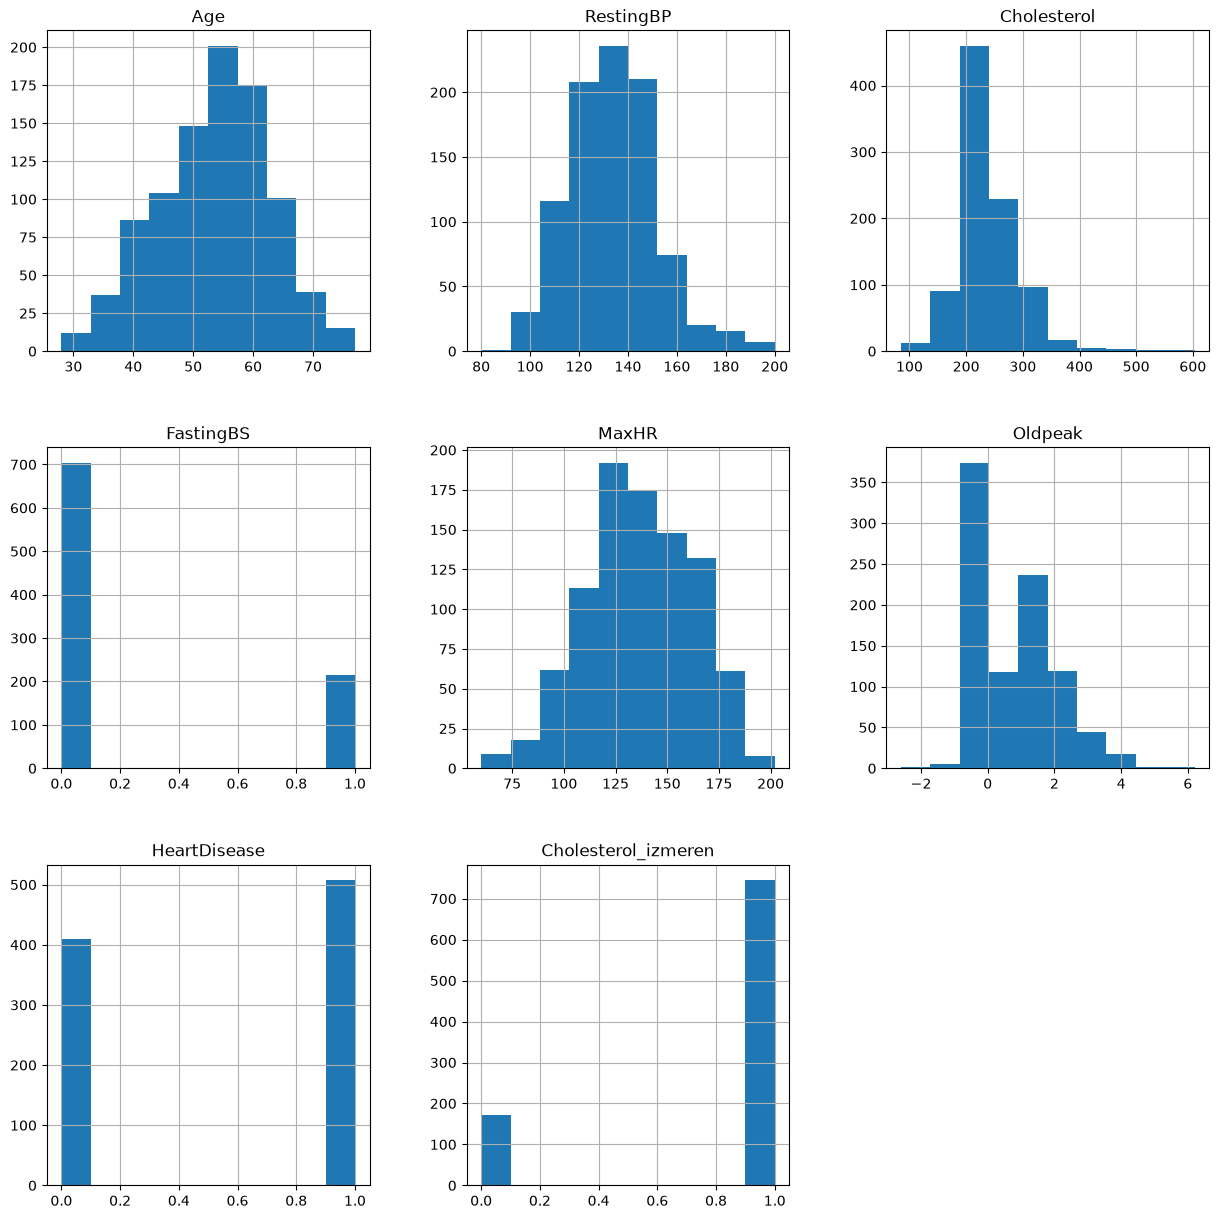

In [74]:
data.hist(figsize=(15, 15))
plt.show()

Prosečne vrednosti numeričkih atributa po klasama:

In [76]:
numericki_atributi = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
data.groupby('HeartDisease')[numericki_atributi].mean()

,Age,RestingBP,Cholesterol,MaxHR,Oldpeak
HeartDisease,,,,,
0,50.551220,130.180488,238.682927,148.151220,0.408049
1,55.899606,134.440945,246.854331,127.655512,1.274213


Bolesni pacijenti su u proseku stariji, imaju nižu maksimalnu srčanu frekvenciju i osetno veću ST depresiju pri naporu. Razlika kod atributa <code>Oldpeak</code> je najizraženija.

Raspodela instanci po klasama za kategoričke atribute:

In [78]:
pd.crosstab(data['ChestPainType'], data['HeartDisease'])

HeartDisease,0,1
ChestPainType,,
ASY,104,392
ATA,149,24
NAP,131,72
TA,26,20


In [79]:
pd.crosstab(data['ST_Slope'], data['HeartDisease'])

HeartDisease,0,1
ST_Slope,,
Down,14,49
Flat,79,381
Up,317,78


In [80]:
pd.crosstab(data['ExerciseAngina'], data['HeartDisease'])

HeartDisease,0,1
ExerciseAngina,,
N,355,192
Y,55,316


In [82]:
pd.crosstab(data['Sex'], data['HeartDisease'])

HeartDisease,0,1
Sex,,
F,143,50
M,267,458


Kod pacijenata bez simptoma (ASY) velika većina ima srčano oboljenje, dok je kod atipične angine (ATA) odnos obrnut. Slično je i sa nagibom ST segmenta, vrednost Flat prati oboljenje, a vrednost Up zdrave pacijente.

# Transformacija kategoričkih atributa

Modeli koje ćemo koristiti rade sa brojevima, pa kategoričke atribute pretvaramo u binarne kolone funkcijom <code>get_dummies()</code>. Parametar <code>drop_first</code> postavljamo na <code>True</code> kako bismo izbacili po jednu kolonu iz svake grupe i time izbegli linearnu zavisnost među atributima.

In [83]:
data = pd.get_dummies(data, drop_first=True, dtype=int)

In [85]:
data.shape

(918, 17)

In [31]:
data.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Cholesterol_izmeren,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0.0,0,1,1,1,0,0,1,0,0,0,1
1,49,160,180,0,156,1.0,1,1,0,0,1,0,1,0,0,1,0
2,37,130,283,0,98,0.0,0,1,1,1,0,0,0,1,0,0,1
3,48,138,214,0,108,1.5,1,1,0,0,0,0,1,0,1,1,0
4,54,150,195,0,122,0.0,0,1,1,0,1,0,1,0,0,0,1


Nakon transformacije skup ima 918 instanci, 16 atributa i jednu ciljnu promenljivu.

# Korelacije

Informacije o korelaciji atributa dobijamo metodom <code>corr()</code> koja izračunava Pirsonov koeficijent korelacije:

In [86]:
data.corr()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Cholesterol_izmeren,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
Age,1.000000,0.263054,0.045535,0.198039,-0.382045,0.258612,0.282039,-0.138919,0.055750,-0.218165,-0.011335,0.032042,-0.230566,0.136798,0.215793,0.185568,-0.258067
RestingBP,0.263054,1.000000,0.086079,0.067896,-0.109771,0.174130,0.117798,0.056137,0.009346,-0.051293,-0.027772,0.049498,-0.113842,0.089219,0.153133,0.109956,-0.105791
Cholesterol,0.045535,0.086079,1.000000,0.024917,-0.001600,0.054500,0.076114,0.055822,-0.111170,-0.005137,-0.060617,-0.044663,-0.043479,-0.032237,0.072828,0.087306,-0.081039
FastingBS,0.198039,0.067896,0.024917,1.000000,-0.131438,0.052698,0.267291,-0.322895,0.120076,-0.140514,-0.039249,0.026885,-0.093028,0.127110,0.060451,0.107006,-0.161730
MaxHR,-0.382045,-0.109771,-0.001600,-0.131438,1.000000,-0.160691,-0.400421,0.279669,-0.189186,0.253735,0.134580,0.100025,0.023801,-0.157879,-0.370425,-0.342581,0.383397
Oldpeak,0.258612,0.174130,0.054500,0.052698,-0.160691,1.000000,0.403951,0.027830,0.105734,-0.262124,-0.106212,0.032231,-0.116719,0.055958,0.408752,0.283295,-0.450577
HeartDisease,0.282039,0.117798,0.076114,0.267291,-0.400421,0.403951,1.000000,-0.319066,0.305445,-0.401924,-0.212964,-0.054790,-0.091580,0.102527,0.494282,0.554134,-0.622164
Cholesterol_izmeren,-0.138919,0.056137,0.055822,-0.322895,0.279669,0.027830,-0.319066,1.000000,-0.172382,0.181418,0.027142,0.046305,-0.020384,-0.138749,-0.082421,-0.110622,0.157926
Sex_M,0.055750,0.009346,-0.111170,0.120076,-0.189186,0.105734,0.305445,-0.172382,1.000000,-0.161522,-0.066486,-0.004031,-0.010634,0.063715,0.190664,0.116077,-0.150942
ChestPainType_ATA,-0.218165,-0.051293,-0.005137,-0.140514,0.253735,-0.262124,-0.401924,0.181418,-0.161522,1.000000,-0.256767,-0.110679,0.107941,-0.046111,-0.300365,-0.304667,0.357588


Za nas su najzanimljivije korelacije atributa sa ciljnom promenljivom:

In [87]:
korelacije = data.corr()['HeartDisease'].sort_values()
korelacije

ST_Slope_Up           -0.622164
ChestPainType_ATA     -0.401924
MaxHR                 -0.400421
Cholesterol_izmeren   -0.319066
ChestPainType_NAP     -0.212964
RestingECG_Normal     -0.091580
ChestPainType_TA      -0.054790
Cholesterol            0.076114
RestingECG_ST          0.102527
RestingBP              0.117798
FastingBS              0.267291
Age                    0.282039
Sex_M                  0.305445
Oldpeak                0.403951
ExerciseAngina_Y       0.494282
ST_Slope_Flat          0.554134
HeartDisease           1.000000
Name: HeartDisease, dtype: float64

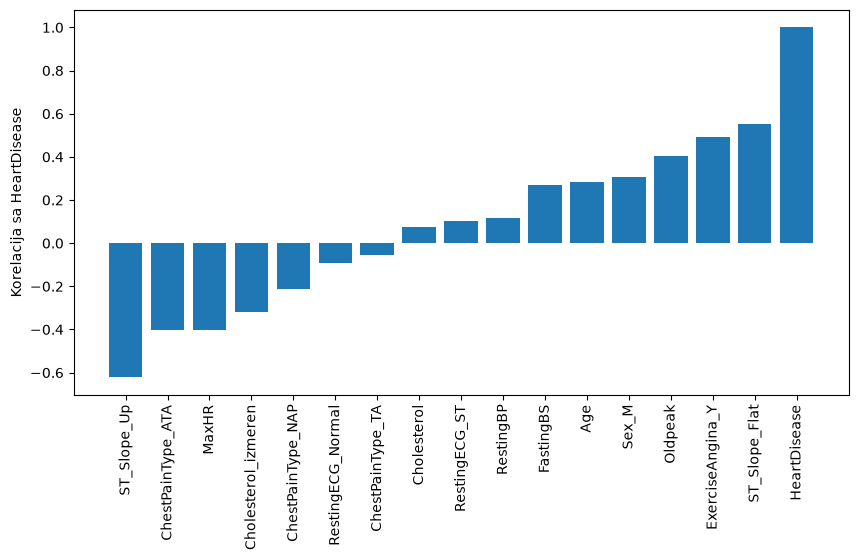

In [88]:
plt.figure(figsize=(10, 5))
plt.bar(korelacije.index, korelacije.values)
plt.xticks(rotation='vertical')
plt.ylabel('Korelacija sa HeartDisease')
plt.show()

Najjaču pozitivnu korelaciju sa oboljenjem imaju ravan nagib ST segmenta (0.55), angina izazvana naporom (0.49) i ST depresija (0.40), a najjaču negativnu uzlazni nagib ST segmenta (-0.62), atipična angina (-0.40) i maksimalna srčana frekvencija (-0.40). Slabu korelaciju imaju <code>Cholesterol</code>, <code>RestingECG_Normal</code> i <code>ChestPainType_TA</code>.

# Zaključak

Skup ima 918 instanci i 11 atributa. To je mali skup, pa ocene modela dobijene na jednoj podeli neće biti pouzdane i koristićemo unakrsnu validaciju. Klase su nebalansirane (55.3% prema 44.7%), pa podelu vršimo stratifikovano, a pored tačnosti pratimo i F1 meru. U koloni <code>Cholesterol</code> bilo je 172 nule, a u koloni <code>RestingBP</code> jedna. Zamenili smo ih medijanom i uveli atribut <code>Cholesterol_izmeren</code>, jer se pokazalo da odsustvo merenja nosi informaciju. Kategoričke atribute smo transformisali funkcijom <code>get_dummies()</code>, pa skup sada ima 16 atributa. Skale atributa su vrlo različite, pa je pre učenja modela potrebno izvršiti standardizaciju.